# Rebuild Aggregate Perturbation Curve (Mean Only)

This notebook loads per-sample results from `results_cache/sample_*/result.json` and regenerates an aggregate perturbation curve **without** `+-1 std` shading.

In [ ]:
# Optional Google Drive mount (only when running in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted.')
except Exception:
    print('Not in Colab; using local filesystem.')

In [12]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# Prefer local workspace path, with fallbacks.
candidate_dirs = [
    Path('/Users/mikhailbelov/Downloads/Thesis/llava_med/results_cache/'),
    Path('/content/drive/Othercomputers/My Mac/Thesis/llava_med/results_cache/'),
    Path('results_cache/'),
    Path('Thesis/llava_med/results_cache/'),
]

out_dir = None
for p in candidate_dirs:
    if p.exists():
        out_dir = p
        break

if out_dir is None:
    raise FileNotFoundError(
        'Could not find results_cache directory. Checked: ' + ', '.join(str(p) for p in candidate_dirs)
    )

print('Using out_dir:', out_dir)

sample_files = sorted(out_dir.glob('sample_*/result.json'))
print('Found sample result files:', len(sample_files))

rows_by_idx = {}
for p in sample_files:
    try:
        with open(p, 'r') as f:
            row = json.load(f)
        idx = int(row.get('sample_idx', -1))
        if idx >= 0:
            rows_by_idx[idx] = row
    except Exception as e:
        print(f'[warn] failed to load {p}: {e}')

all_rows = [rows_by_idx[k] for k in sorted(rows_by_idx.keys())]
print('Usable unique sample rows:', len(all_rows))

Using out_dir: /Users/mikhailbelov/Downloads/Thesis/llava_med/results_cache
Found sample result files: 164
Usable unique sample rows: 164


In [13]:
# Build method -> list of per-sample mean_drops_by_ratio
drops_by_method = defaultdict(list)

for row in all_rows:
    eval_dict = row.get('eval', {})
    if not isinstance(eval_dict, dict):
        continue

    for method, metric in eval_dict.items():
        if not isinstance(metric, dict):
            continue

        drops_raw = metric.get('mean_drops_by_ratio', None)
        drops_list = None

        # Newer/alternate format: dict like {'0.1': val, '0.2': val, ...}
        if isinstance(drops_raw, dict) and drops_raw:
            try:
                ordered_keys = sorted(drops_raw.keys(), key=lambda k: float(k))
                drops_list = [float(drops_raw[k]) for k in ordered_keys]
            except Exception:
                drops_list = None

        # Older format: list [val_at_0.1, val_at_0.2, ...]
        elif isinstance(drops_raw, list) and len(drops_raw) > 0:
            try:
                drops_list = [float(x) for x in drops_raw]
            except Exception:
                drops_list = None

        if drops_list is not None and len(drops_list) > 0:
            drops_by_method[method].append(drops_list)

print('Methods found:', sorted(drops_by_method.keys()))
for m in sorted(drops_by_method.keys()):
    print(f'{m}: {len(drops_by_method[m])} curves')

Methods found: ['attention', 'gmar_l1', 'gmar_l2', 'gradcam', 'random']
attention: 163 curves
gmar_l1: 163 curves
gmar_l2: 163 curves
gradcam: 163 curves
random: 164 curves


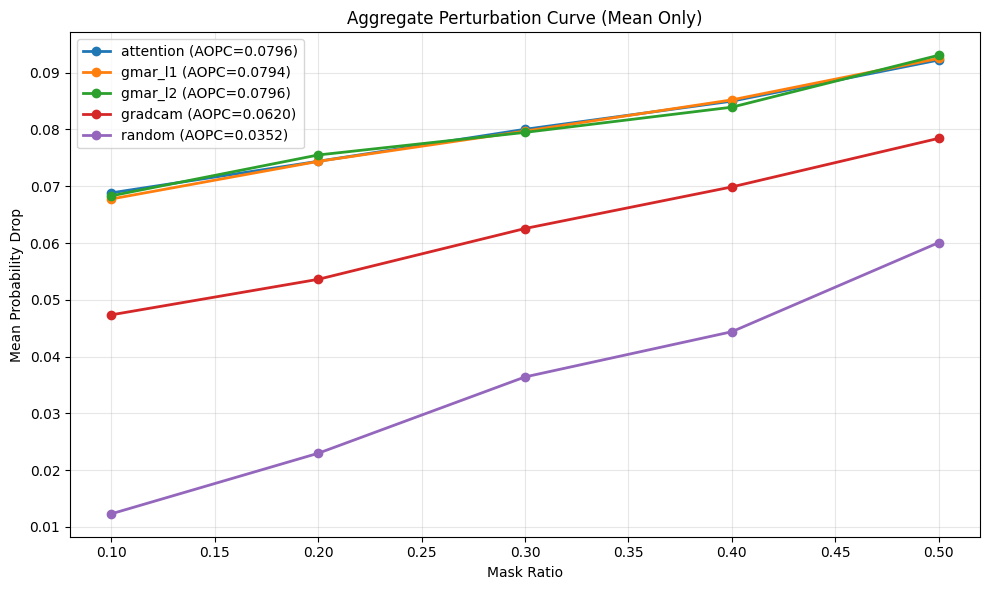

Saved: /Users/mikhailbelov/Downloads/Thesis/llava_med/results_cache/aggregate_perturbation_no_std.png


In [14]:
# Optional: read mask ratios from config if available
config_path = out_dir / 'config.json'
mask_ratios = None
if config_path.exists():
    try:
        with open(config_path, 'r') as f:
            cfg = json.load(f)
        mr = cfg.get('mask_ratios', None)
        if isinstance(mr, list) and len(mr) > 0:
            mask_ratios = [float(x) for x in mr]
    except Exception as e:
        print(f'[warn] failed to parse config mask_ratios: {e}')

# Compute mean curve and mean AOPC per method (no std shading)
mean_curves = {}
aopc_by_method = defaultdict(list)

for row in all_rows:
    eval_dict = row.get('eval', {})
    if not isinstance(eval_dict, dict):
        continue
    for method, metric in eval_dict.items():
        if not isinstance(metric, dict):
            continue
        if 'aopc' in metric:
            try:
                aopc_by_method[method].append(float(metric['aopc']))
            except Exception:
                pass

for method, curves in drops_by_method.items():
    if not curves:
        continue
    min_len = min(len(c) for c in curves)
    arr = np.array([c[:min_len] for c in curves], dtype=float)
    mean_curves[method] = arr.mean(axis=0)

if not mean_curves:
    raise RuntimeError('No usable curves found in per-sample result.json files.')

mean_aopc = {}
for method in mean_curves.keys():
    vals = aopc_by_method.get(method, [])
    mean_aopc[method] = float(np.mean(vals)) if vals else float('nan')

# X-axis
first_len = len(next(iter(mean_curves.values())))
if mask_ratios is not None and len(mask_ratios) >= first_len:
    x = np.array(mask_ratios[:first_len], dtype=float)
    x_label = 'Mask Ratio'
else:
    x = np.arange(1, first_len + 1)
    x_label = 'Mask Step'

# Plot mean-only aggregate curves
plt.figure(figsize=(10, 6))
for method in sorted(mean_curves.keys()):
    aopc_val = mean_aopc.get(method, float('nan'))
    if np.isfinite(aopc_val):
        label = f'{method} (AOPC={aopc_val:.4f})'
    else:
        label = method
    plt.plot(x, mean_curves[method], marker='o', linewidth=2, label=label)

plt.title('Aggregate Perturbation Curve (Mean Only)')
plt.xlabel(x_label)
plt.ylabel('Mean Probability Drop')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = out_dir / 'aggregate_perturbation_no_std.png'
plt.savefig(out_path, dpi=150)
plt.show()

print('Saved:', out_path)

## Statistical Diagnosis: GMAR vs Attention

This section extends the aggregate plot with per-sample paired analysis.

What it does:
- Builds paired AOPC vectors for each method from `all_rows`
- Compares each method against `attention`
- Computes effect size (`mean_delta`), bootstrap 95% CI, and exact two-sided sign-test p-value
- Visualizes per-sample delta distributions

Interpretation:
- If CI includes 0 and sign-test p-value is not small, there is no reliable advantage in this setup.
- If CI is entirely above 0, the method reliably outperforms attention for this protocol.

In [15]:
import math

# Build per-sample AOPC vectors by method
per_sample_aopc = defaultdict(dict)
for row in all_rows:
    idx = row.get('sample_idx', None)
    if idx is None:
        continue
    eval_dict = row.get('eval', {})
    if not isinstance(eval_dict, dict):
        continue
    for method, metric in eval_dict.items():
        if isinstance(metric, dict) and ('aopc' in metric):
            try:
                per_sample_aopc[idx][method] = float(metric['aopc'])
            except Exception:
                pass

methods = sorted({m for d in per_sample_aopc.values() for m in d.keys()})
print('Methods with per-sample AOPC:', methods)
print('Total samples loaded:', len(per_sample_aopc))

if 'attention' not in methods:
    raise RuntimeError("'attention' method is required for pairwise comparison but was not found.")


def bootstrap_ci_mean(x, n_boot=10000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return (np.nan, np.nan)
    samples = rng.choice(x, size=(n_boot, n), replace=True)
    means = samples.mean(axis=1)
    lo = float(np.quantile(means, alpha / 2.0))
    hi = float(np.quantile(means, 1.0 - alpha / 2.0))
    return (lo, hi)


def two_sided_sign_test_pvalue(deltas):
    # Exact two-sided sign test around zero, ignoring exact ties.
    d = np.asarray(deltas, dtype=float)
    pos = int(np.sum(d > 0))
    neg = int(np.sum(d < 0))
    n = pos + neg
    if n == 0:
        return np.nan, pos, neg, int(np.sum(d == 0))

    k = min(pos, neg)
    cdf = 0.0
    for i in range(k + 1):
        cdf += math.comb(n, i) * (0.5 ** n)
    p_two = min(1.0, 2.0 * cdf)
    ties = int(np.sum(d == 0))
    return float(p_two), pos, neg, ties


comparison_rows = []
for method in methods:
    if method == 'attention':
        continue

    paired_idxs = sorted(
        i for i, d in per_sample_aopc.items() if ('attention' in d and method in d)
    )
    if not paired_idxs:
        continue

    att = np.array([per_sample_aopc[i]['attention'] for i in paired_idxs], dtype=float)
    met = np.array([per_sample_aopc[i][method] for i in paired_idxs], dtype=float)
    delta = met - att  # >0 means method better than attention for AOPC

    mean_delta = float(np.mean(delta))
    median_delta = float(np.median(delta))
    ci_lo, ci_hi = bootstrap_ci_mean(delta)
    p_sign, n_pos, n_neg, n_ties = two_sided_sign_test_pvalue(delta)

    comparison_rows.append({
        'method': method,
        'n_pairs': int(len(delta)),
        'mean_delta': mean_delta,
        'median_delta': median_delta,
        'ci95_low': ci_lo,
        'ci95_high': ci_hi,
        'sign_test_p': p_sign,
        'n_pos': n_pos,
        'n_neg': n_neg,
        'n_ties': n_ties,
        'mean_method_aopc': float(np.mean(met)),
        'mean_attention_aopc': float(np.mean(att)),
    })

comparison_rows = sorted(comparison_rows, key=lambda r: r['method'])

print('\nPairwise summary (method - attention):')
for r in comparison_rows:
    print(
        f"{r['method']:12s} n={r['n_pairs']:4d} "
        f"mean_delta={r['mean_delta']:+.6f} "
        f"median_delta={r['median_delta']:+.6f} "
        f"CI95=[{r['ci95_low']:+.6f}, {r['ci95_high']:+.6f}] "
        f"p_sign={r['sign_test_p']:.4g} "
        f"(+/-/0)={r['n_pos']}/{r['n_neg']}/{r['n_ties']}"
    )

Methods with per-sample AOPC: ['attention', 'gmar_l1', 'gmar_l2', 'gradcam', 'random']
Total samples loaded: 164

Pairwise summary (method - attention):
gmar_l1      n= 164 mean_delta=-0.000180 median_delta=-0.000691 CI95=[-0.001850, +0.001496] p_sign=0.21 (+/-/0)=73/90/1
gmar_l2      n= 164 mean_delta=-0.000034 median_delta=-0.000459 CI95=[-0.001626, +0.001525] p_sign=0.4336 (+/-/0)=76/87/1
gradcam      n= 164 mean_delta=-0.017620 median_delta=-0.008795 CI95=[-0.022695, -0.012653] p_sign=8.858e-07 (+/-/0)=50/113/1
random       n= 164 mean_delta=-0.044377 median_delta=-0.029365 CI95=[-0.054053, -0.035203] p_sign=2.981e-16 (+/-/0)=31/133/0


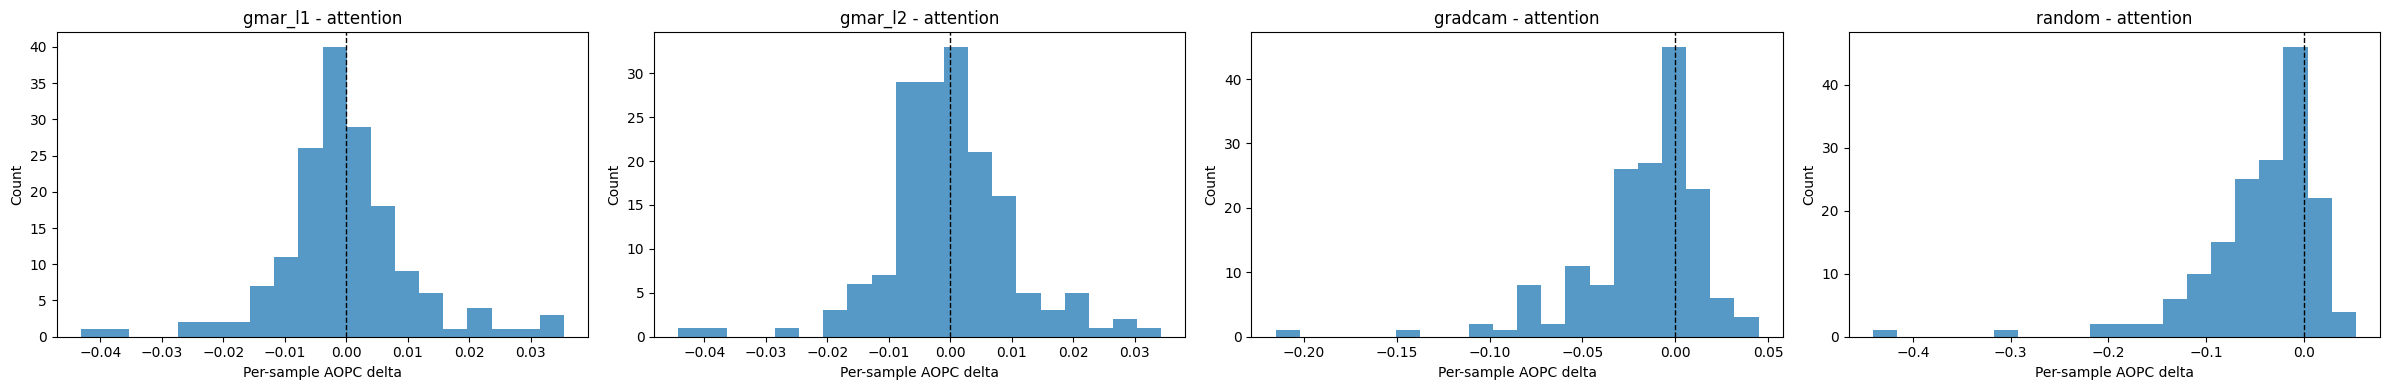


Compact table:
method          n       mean_d        med_d       ci_low      ci_high     p_sign
--------------------------------------------------------------------------------
gmar_l1       164    -0.000180    -0.000691    -0.001850     0.001496       0.21
gmar_l2       164    -0.000034    -0.000459    -0.001626     0.001525     0.4336
gradcam       164    -0.017620    -0.008795    -0.022695    -0.012653  8.858e-07
random        164    -0.044377    -0.029365    -0.054053    -0.035203  2.981e-16

Saved stats: /Users/mikhailbelov/Downloads/Thesis/llava_med/results_cache/gmar_vs_attention_stats.json


In [16]:
# Visual diagnostics: per-sample delta histograms and an at-a-glance table
if not comparison_rows:
    raise RuntimeError('No pairwise comparisons available. Check that attention and other methods have per-sample AOPC values.')

# Create small helper dict to reuse paired deltas for plotting
delta_by_method = {}
for r in comparison_rows:
    m = r['method']
    paired_idxs = sorted(i for i, d in per_sample_aopc.items() if ('attention' in d and m in d))
    att = np.array([per_sample_aopc[i]['attention'] for i in paired_idxs], dtype=float)
    met = np.array([per_sample_aopc[i][m] for i in paired_idxs], dtype=float)
    delta_by_method[m] = met - att

n_methods = len(delta_by_method)
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 4), squeeze=False)
axes = axes[0]

for ax, (m, d) in zip(axes, sorted(delta_by_method.items())):
    ax.hist(d, bins=20, alpha=0.75)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{m} - attention')
    ax.set_xlabel('Per-sample AOPC delta')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print('\nCompact table:')
header = (
    f"{'method':12s} {'n':>4s} {'mean_d':>12s} {'med_d':>12s} "
    f"{'ci_low':>12s} {'ci_high':>12s} {'p_sign':>10s}"
)
print(header)
print('-' * len(header))
for r in comparison_rows:
    print(
        f"{r['method']:12s} {r['n_pairs']:4d} "
        f"{r['mean_delta']:12.6f} {r['median_delta']:12.6f} "
        f"{r['ci95_low']:12.6f} {r['ci95_high']:12.6f} {r['sign_test_p']:10.4g}"
    )

# Save a machine-readable summary for reports
stats_out = out_dir / 'gmar_vs_attention_stats.json'
with open(stats_out, 'w') as f:
    json.dump(comparison_rows, f, indent=2)
print('\nSaved stats:', stats_out)

In [18]:
# Research-style conclusion from the computed statistics

def verdict_for_row(r):
    ci_has_zero = (r['ci95_low'] <= 0.0 <= r['ci95_high'])
    if (r['ci95_low'] > 0.0) and (r['sign_test_p'] < 0.05):
        return 'better_than_attention'
    if (r['ci95_high'] < 0.0) and (r['sign_test_p'] < 0.05):
        return 'worse_than_attention'
    if ci_has_zero:
        return 'no_reliable_difference'
    return 'inconclusive'

print('Conclusion summary:')
for r in comparison_rows:
    v = verdict_for_row(r)
    print(
        f"- {r['method']}: {v}; "
        f"mean delta={r['mean_delta']:+.6f}, "
        f"95% CI=[{r['ci95_low']:+.6f}, {r['ci95_high']:+.6f}], "
        f"sign-test p={r['sign_test_p']:.4g}"
    )

print('\nBottom line for this setup:')
print('- GMAR-L1 and GMAR-L2 show no reliable improvement over attention rollout (CIs include 0; non-significant sign tests).')
print('- Therefore, your intuition is correct: this should be treated as a hypothesis-testing/diagnostic finding, not as a simple plotting artifact.')
print('- This is an interesting boundary-condition result for this perturbation protocol.')

Conclusion summary:
- gmar_l1: no_reliable_difference; mean delta=-0.000180, 95% CI=[-0.001850, +0.001496], sign-test p=0.21
- gmar_l2: no_reliable_difference; mean delta=-0.000034, 95% CI=[-0.001626, +0.001525], sign-test p=0.4336
- gradcam: worse_than_attention; mean delta=-0.017620, 95% CI=[-0.022695, -0.012653], sign-test p=8.858e-07
- random: worse_than_attention; mean delta=-0.044377, 95% CI=[-0.054053, -0.035203], sign-test p=2.981e-16

Bottom line for this setup:
- GMAR-L1 and GMAR-L2 show no reliable improvement over attention rollout (CIs include 0; non-significant sign tests).
- Therefore, your intuition is correct: this should be treated as a hypothesis-testing/diagnostic finding, not as a simple plotting artifact.
- This is an interesting boundary-condition result for this perturbation protocol.


In [17]:
# Inspect available row keys to locate caption text/length fields
if not all_rows:
    raise RuntimeError('No rows loaded. Run earlier loading cells first.')

print('Top-level keys in first row:')
print(sorted(all_rows[0].keys()))

if isinstance(all_rows[0].get('sample', None), dict):
    print('\nSample subkeys:')
    print(sorted(all_rows[0]['sample'].keys()))

if isinstance(all_rows[0].get('metadata', None), dict):
    print('\nMetadata subkeys:')
    print(sorted(all_rows[0]['metadata'].keys()))

Top-level keys in first row:
['eval', 'generated_text', 'ner_variants', 'num_content_tokens', 'num_generated_tokens', 'reference_caption', 'sample_id', 'sample_idx']


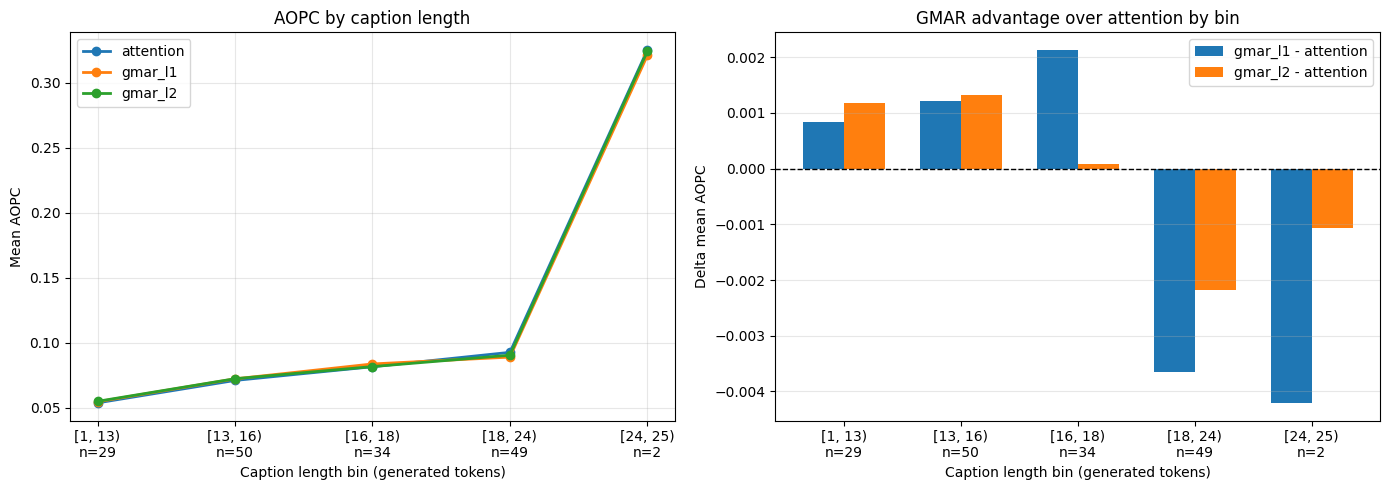

Saved: /Users/mikhailbelov/Downloads/Thesis/llava_med/results_cache/gmar_vs_attention_by_caption_length.png

Bin summary:
     [1, 13) n= 29 | att=0.053649 gm1=0.054493 gm2=0.054835 | gm1-att=+0.000844 gm2-att=+0.001186
    [13, 16) n= 50 | att=0.070913 gm1=0.072130 gm2=0.072232 | gm1-att=+0.001217 gm2-att=+0.001319
    [16, 18) n= 34 | att=0.081461 gm1=0.083592 gm2=0.081552 | gm1-att=+0.002131 gm2-att=+0.000092
    [18, 24) n= 49 | att=0.092521 gm1=0.088870 gm2=0.090338 | gm1-att=-0.003650 gm2-att=-0.002182
    [24, 25) n=  2 | att=0.325107 gm1=0.320900 gm2=0.324037 | gm1-att=-0.004207 gm2-att=-0.001070


In [19]:
# GMAR vs Attention by caption length bins

def _caption_len_from_row(row):
    # Prefer explicit generated-token count from the run cache.
    n = row.get('num_generated_tokens', None)
    try:
        if n is not None and int(n) > 0:
            return int(n)
    except Exception:
        pass

    # Fallbacks if token count is missing.
    txt = row.get('generated_text', None) or row.get('reference_caption', None) or ''
    return len(str(txt).strip().split())


# Collect per-sample tuples: (length, attention, gmar_l1, gmar_l2)
records = []
for row in all_rows:
    eval_dict = row.get('eval', {})
    if not isinstance(eval_dict, dict):
        continue

    length = _caption_len_from_row(row)

    def _get_aopc(method):
        metric = eval_dict.get(method, None)
        if isinstance(metric, dict) and ('aopc' in metric):
            try:
                return float(metric['aopc'])
            except Exception:
                return np.nan
        return np.nan

    att = _get_aopc('attention')
    gm1 = _get_aopc('gmar_l1')
    gm2 = _get_aopc('gmar_l2')

    if np.isfinite(att) and (np.isfinite(gm1) or np.isfinite(gm2)):
        records.append((length, att, gm1, gm2))

if not records:
    raise RuntimeError('No valid paired records for caption-length analysis.')

arr = np.array(records, dtype=float)
lengths = arr[:, 0]
att_all = arr[:, 1]
gm1_all = arr[:, 2]
gm2_all = arr[:, 3]

# Build length bins from quantiles for balanced sample counts.
q_edges = np.quantile(lengths, [0.0, 0.25, 0.5, 0.75, 1.0])
q_edges = np.unique(np.round(q_edges).astype(int))
if len(q_edges) < 3:
    # Fallback fixed-width bins if quantiles collapse.
    lo, hi = int(np.min(lengths)), int(np.max(lengths))
    step = max(1, (hi - lo) // 4)
    q_edges = np.array([lo, lo + step, lo + 2 * step, lo + 3 * step, hi + 1], dtype=int)

# Ensure right-open final edge includes max.
if q_edges[-1] <= np.max(lengths):
    q_edges = np.append(q_edges, int(np.max(lengths)) + 1)

bin_labels = []
bin_centers = []
n_per_bin = []
att_mean = []
gm1_mean = []
gm2_mean = []

delta_gm1 = []
delta_gm2 = []

for i in range(len(q_edges) - 1):
    left = q_edges[i]
    right = q_edges[i + 1]
    m = (lengths >= left) & (lengths < right)

    n = int(np.sum(m))
    if n == 0:
        continue

    label = f'[{left}, {right})'
    bin_labels.append(label)
    bin_centers.append((left + right) / 2.0)
    n_per_bin.append(n)

    att_b = att_all[m]
    gm1_b = gm1_all[m]
    gm2_b = gm2_all[m]

    att_mu = float(np.nanmean(att_b))
    gm1_mu = float(np.nanmean(gm1_b))
    gm2_mu = float(np.nanmean(gm2_b))

    att_mean.append(att_mu)
    gm1_mean.append(gm1_mu)
    gm2_mean.append(gm2_mu)

    delta_gm1.append(gm1_mu - att_mu)
    delta_gm2.append(gm2_mu - att_mu)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(bin_labels))

axes[0].plot(x, att_mean, marker='o', linewidth=2, label='attention')
axes[0].plot(x, gm1_mean, marker='o', linewidth=2, label='gmar_l1')
axes[0].plot(x, gm2_mean, marker='o', linewidth=2, label='gmar_l2')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{b}\nn={n}' for b, n in zip(bin_labels, n_per_bin)], rotation=0)
axes[0].set_xlabel('Caption length bin (generated tokens)')
axes[0].set_ylabel('Mean AOPC')
axes[0].set_title('AOPC by caption length')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

w = 0.35
axes[1].bar(x - w / 2, delta_gm1, width=w, label='gmar_l1 - attention')
axes[1].bar(x + w / 2, delta_gm2, width=w, label='gmar_l2 - attention')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{b}\nn={n}' for b, n in zip(bin_labels, n_per_bin)], rotation=0)
axes[1].set_xlabel('Caption length bin (generated tokens)')
axes[1].set_ylabel('Delta mean AOPC')
axes[1].set_title('GMAR advantage over attention by bin')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
out_len_plot = out_dir / 'gmar_vs_attention_by_caption_length.png'
plt.savefig(out_len_plot, dpi=150)
plt.show()

print('Saved:', out_len_plot)
print('\nBin summary:')
for i in range(len(bin_labels)):
    print(
        f"{bin_labels[i]:>12s} n={n_per_bin[i]:3d} | "
        f"att={att_mean[i]:.6f} gm1={gm1_mean[i]:.6f} gm2={gm2_mean[i]:.6f} | "
        f"gm1-att={delta_gm1[i]:+.6f} gm2-att={delta_gm2[i]:+.6f}"
    )